# Trabalho Computacional 12
## PPGEE 2166 Processos Estocásticos (2026.1)
- Discente: Thiago Tomás de Paula (242104677)
- Data: 15/07/2026

### Item 12.1 

Idêntico ao Trabalho 7, só que agora você deve usar o arquivo `DataSet_folhas_celular.csv`.

---

### Análise exploratória dos dados

Esta etapa do estudo gera e analisa os seguintes itens:

0. retrato de dados faltantes ou indefinidos;
1. listagem das classes: nomes, descrições e unidades;
2. listagem das features: nomes, descrições e unidades;
3. gráficos de dispersões e histogramas das features;
4. matriz de correlação de Pearson entre as features desconsiderando classes;
5. matriz de correlação de Pearson entre as features por cada classe. 

**Carregamento dos dados.**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo para os gráficos
COLORMAP = "Set1"
sns.set_style('whitegrid')
sns.set_palette(COLORMAP)
plt.set_cmap(COLORMAP)

# Guarda os dados do arquivo CSV em um DataFrame do Pandas
caminho_dos_dados = "DataSet_folhas_celular.csv"

# O dataset não tem rótulos nas colunas por algum motivo, então vamos definir os nomes das colunas manualmente
COLUNA_CLASSE = "especie"
colunas = [f"f{i}" for i in range(1, 226)] + [COLUNA_CLASSE]
dados = pd.read_csv(caminho_dos_dados, header=None, names=colunas)

<Figure size 640x480 with 0 Axes>

**Checagem dos dados.** 

A rigor, o dataset é completamente anonimizado, tornando incerta qualquer interpretação.
Dado o nome do arquivo, supõe-se que 
o dataset é uma coleção de dados de plantas.
Cada uma das 2400 linhas do dataset é o registro de uma planta, 
e cada uma das 227 colunas um tipo registro sobre a planta.
Uma destas colunas, `especie`, informa a espécie da planta, um inteiro entre 0 e 29. 

A figura abaixo mostra que não há dados faltantes/indefinidos para nenhuma entrada no dataset.

<Axes: >

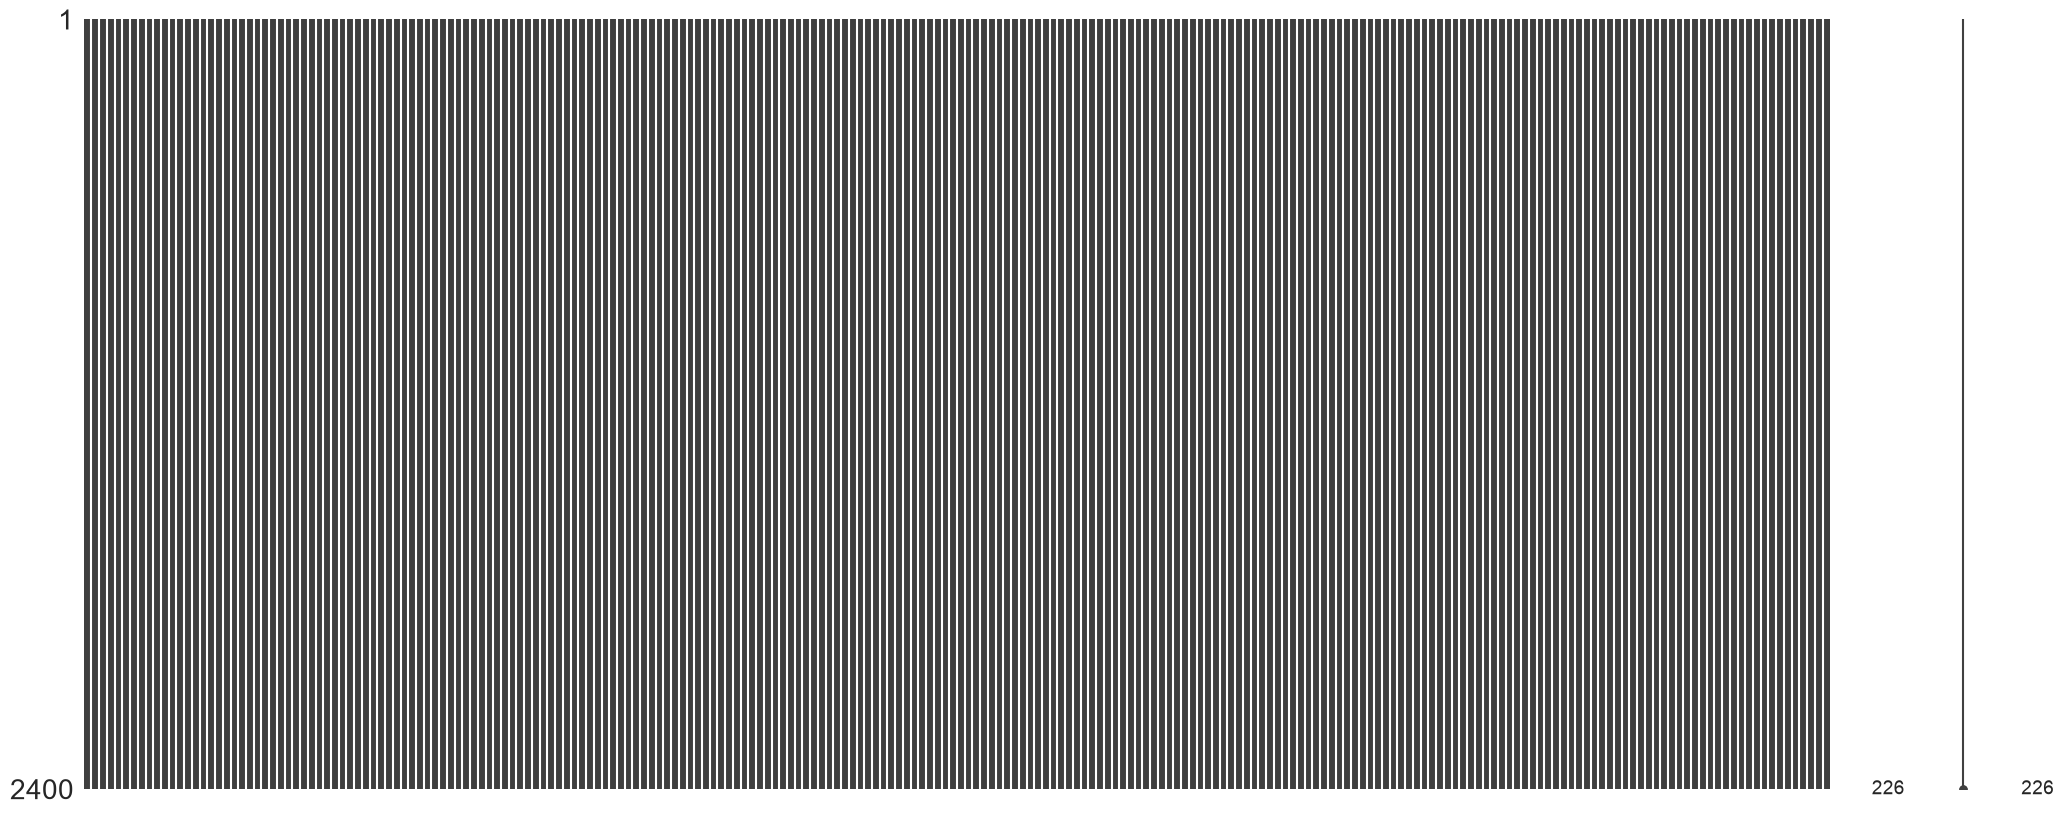

In [2]:
# 0. retrato de dados faltantes ou indefinidos
import missingno as msno
msno.matrix(dados)

**Classes.**

A coluna `especie` possui 30 valores, de 0 a 29. 
O dataset é muito bem balanceado, com aproximadamente 80 amostras por classe.

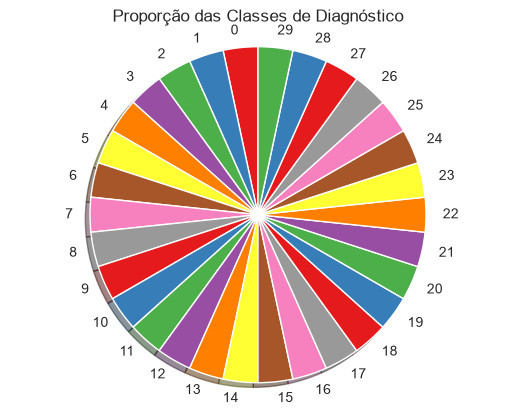

In [3]:
# 1. listagem das classes: nomes, descrições e unidades. 
def plotar_proporcao_classes(dados, coluna_classe=COLUNA_CLASSE, colormap=COLORMAP, titulo="Proporção das Classes de Diagnóstico", ax=None):
    _valores_proporcionais = dados[coluna_classe].value_counts(normalize=True).mul(100).round(2)
    _valores_absolutos = dados[coluna_classe].value_counts()
    _df_classes = pd.DataFrame({
        "Classe": _valores_absolutos.index, 
        "Quantidade": _valores_absolutos.values, 
        "Proporção (%)": _valores_proporcionais.values
    })

    # Gráfico de pizza para visualização da proporção e quantidade das classes
    if ax is None:
        _, ax = plt.subplots()
    pie = ax.pie(_df_classes["Quantidade"], labels=_df_classes["Classe"], shadow=True, startangle=90)
    _ = ax.set_title(titulo)
    _ = plt.axis('equal')

plotar_proporcao_classes(dados)

**Features.**

O dataset possui 225 features ao todo. O significado de nenhuma delas é conhecido, mas todas são numéricas.

**Correlações.**

A matriz de correlação de Pearson entre as features é apresentada a seguir. 

Vê-se que todas as features são altamente correlacionada com pelo menos uma outra feature, e que há aglomerados de features altamente correlacionadas entre si.
Modelos que necessitem da inversão da matriz de covariância, como o LDA, podem ter problemas de singularidade.

<Axes: >

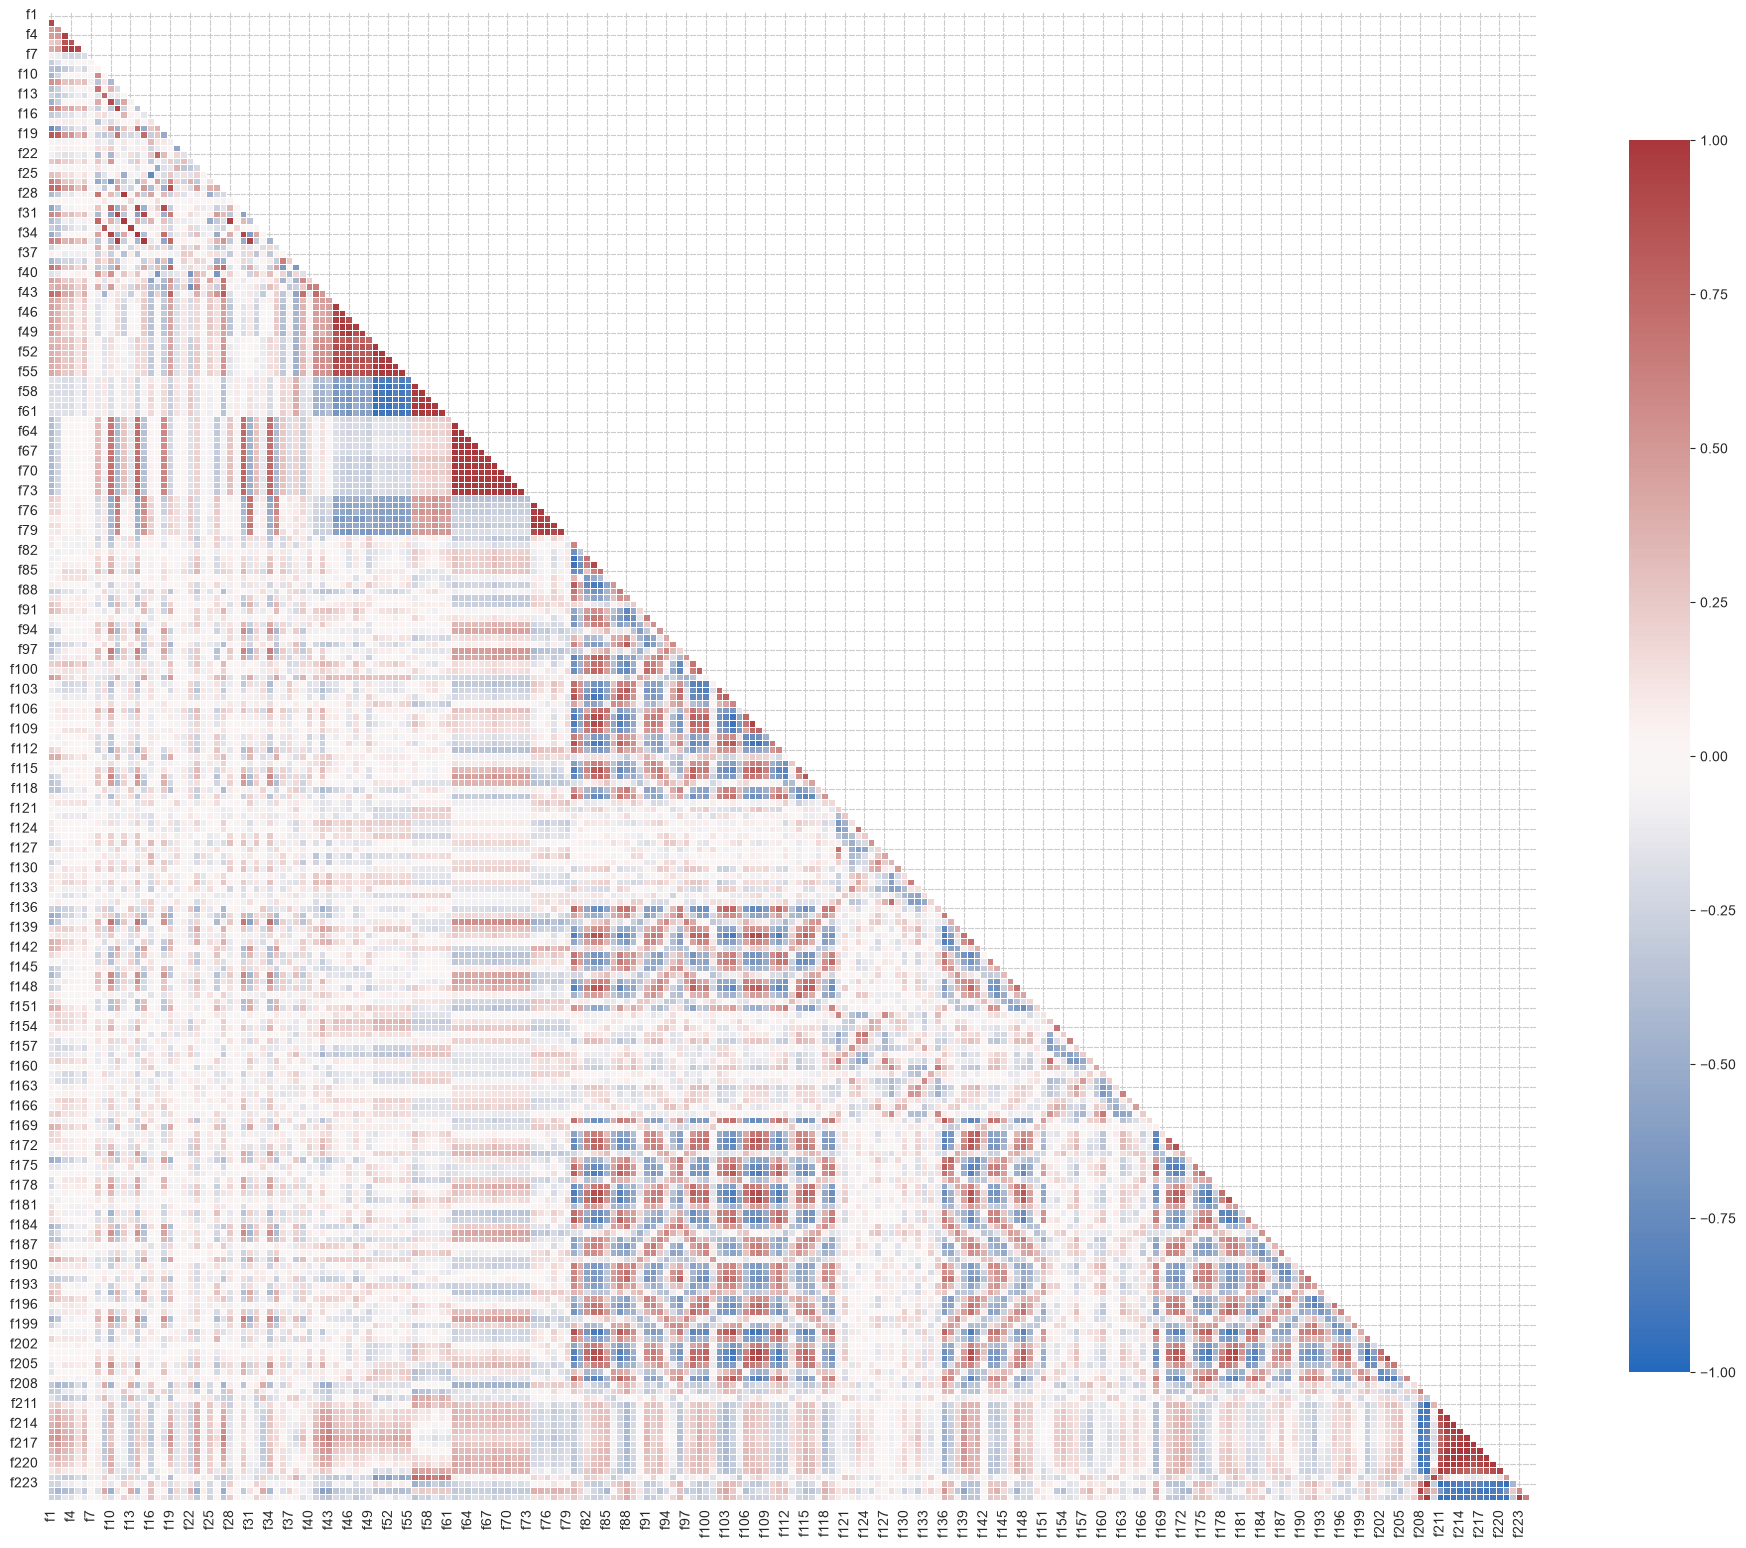

In [4]:
# 4. matriz de correlação de Pearson entre as features desconsiderando classes
import numpy as np
plt.figure(figsize=(24, 20))
matriz_correlacao = dados.drop([COLUNA_CLASSE], axis=1).corr(method='pearson')
mascara_triangular = np.triu(np.ones_like(matriz_correlacao, dtype=bool))
sns.heatmap(matriz_correlacao, vmin=-1, vmax=1, cmap="vlag", square=True, cbar_kws={"shrink": .8}, linewidths=.5, mask=mascara_triangular)

### Comparação de performance em apenas um caso

Terminada a análise exploratória, as amostras do dataset são preparadas para classificação.

A preparação consiste em dois passos: o embaralhamento de amostras, e a partição das amostras treino (80%) e teste (20%).

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(dados.drop([COLUNA_CLASSE], axis=1), dados[COLUNA_CLASSE], test_size=0.2, random_state=42, shuffle=True)

A seguir, o conjunto de treino é usado para contruir três classificadores baseados em discriminante da literatura de aprendizagem supervisionada:
- Naïve Bayes
- Linear Discriminant Analysis (LDA)
- Quadratic Discriminant Analysis (QDA)

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

naive_bayes = GaussianNB()
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis(solver='eigen', shrinkage=1e-3)

naive_bayes.fit(x_train, y_train)
lda.fit(x_train, y_train)
qda.fit(x_train, y_train)

,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'eigen'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",0.001
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Unique class labels.","ndarray[int64](30,)","[ 0, 1, 2,...,27,28,29]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](225,)","['f1','f2','f3',...,'f223','f224','f225']"
"means_ means_: array-like of shape (n_classes, n_features)Class-wise means.","ndarray[float64](30, 225)","[[0. ,0. ,0. ,...,0.05,0.13,0.45], [0. ,0. ,0. ,...,0.05,0.12,0.43], [0. ,0. ,0. ,...,0.06,0.13,0.45], ..., [0. ,0. ,0. ,...,0.06,0.13,0.45], [0. ,0. ,0. ,...,0.05,0.13,0.45], [0. ,0. ,0. ,...,0.06,0.13,0.45]]"


Aqui, os modelos treinados são aplicados no conjunto de teste.

In [7]:
naive_bayes_predicoes = naive_bayes.predict(x_test)
lda_predicoes = lda.predict(x_test)
qda_predicoes = qda.predict(x_test)

Para fins de análise de desempenho, são calculadas as acurácias, os valores de F1, e exibidas as matrizes de confusão de cada modelo.

Matrizes relativas são normalizadas pela linha da matriz, i.e., a quantidade de elementos da classe verdadeira.

Nesta configuração, a diagonal da matriz são as taxas de verdadeiros positivos, e os elementos na diagonal secundária, as de falsos negativos/positivos.

A classe positiva é a de presença de Alzheimer, e a negativa, a de ausência de Alzheimer.

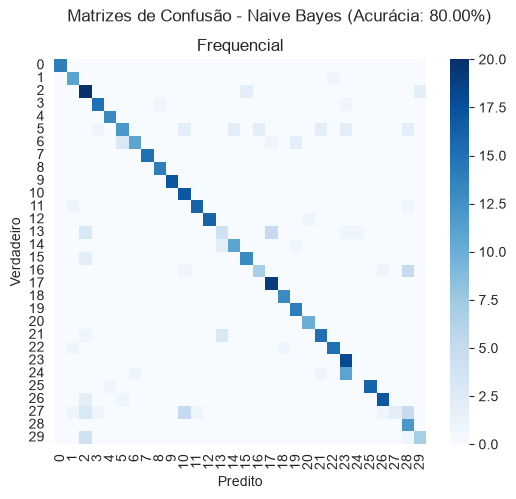

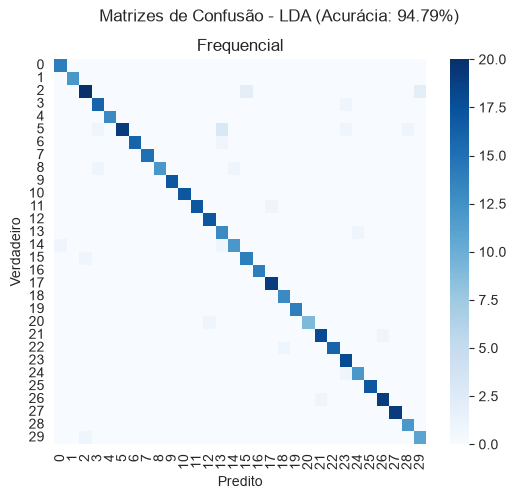

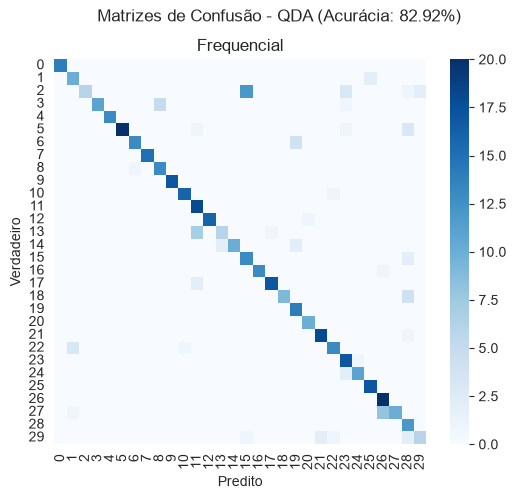

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

naive_bayes_acuracia = accuracy_score(y_test, naive_bayes_predicoes)
lda_acuracia = accuracy_score(y_test, lda_predicoes)
qda_acuracia = accuracy_score(y_test, qda_predicoes)

def plota_matriz_confusao(y_true, y_pred, classes, titulo="Matrizes de Confusão"):
    cm_abs = confusion_matrix(y_true, y_pred, labels=classes)
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
    hmap_args = {
        "annot": False,
        "cmap": "Blues",
        "xticklabels": classes,
        "yticklabels": classes,
    }
    sns.heatmap(cm_abs, fmt='d', ax=ax, **hmap_args)
    _ = ax.set_xlabel('Predito')
    _ = ax.set_ylabel('Verdadeiro')
    _ = ax.set_title('Frequencial')
    fig.suptitle(titulo)

for modelo, acc, preds in [
    ("Naive Bayes", naive_bayes_acuracia, naive_bayes_predicoes), 
    ("LDA", lda_acuracia, lda_predicoes), 
    ("QDA", qda_acuracia, qda_predicoes)
]:
    plota_matriz_confusao(
        y_test, 
        preds, 
        classes=[i for i in range (30)], 
        titulo=f"Matrizes de Confusão - {modelo} (Acurácia: {acc:.2%})"
    )

Vê-se que apesar de todos os modelos terem tido bons resultados, o LDA se demonstrou claramente superior aos demais, com acurácia de 94.79%.

Resta verificar se este nível de desempenho dos classificadores, e a diferença entre eles, é estatisticamente representativa. 

### Comparação de performance média

No item anterior, a semente aletória do embaralhamento de amostras foi fixado. 
Aqui, ele assume 10 valores distintos, para os quais o processo de treino, teste e avaliação é repetido. 
Ao final, são apresentados os valores médios das métricas (acurácia, matriz de confusão, F1).

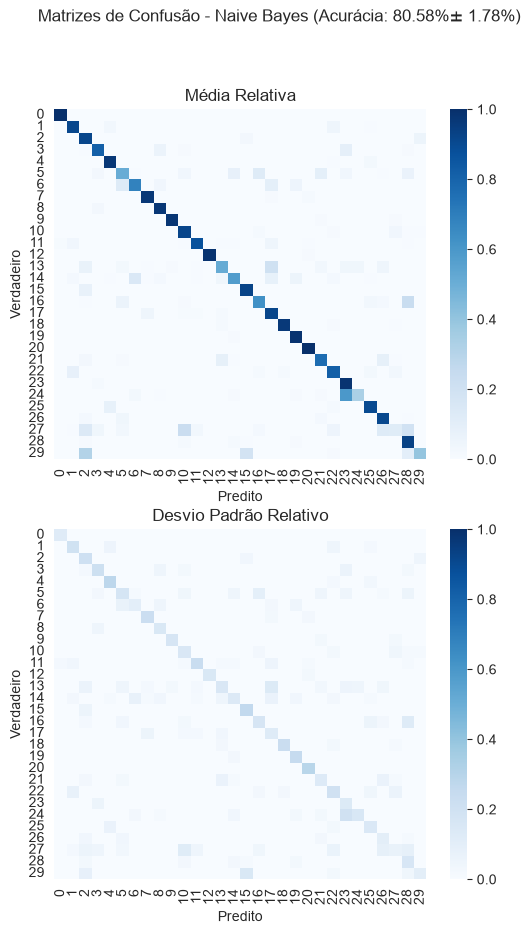

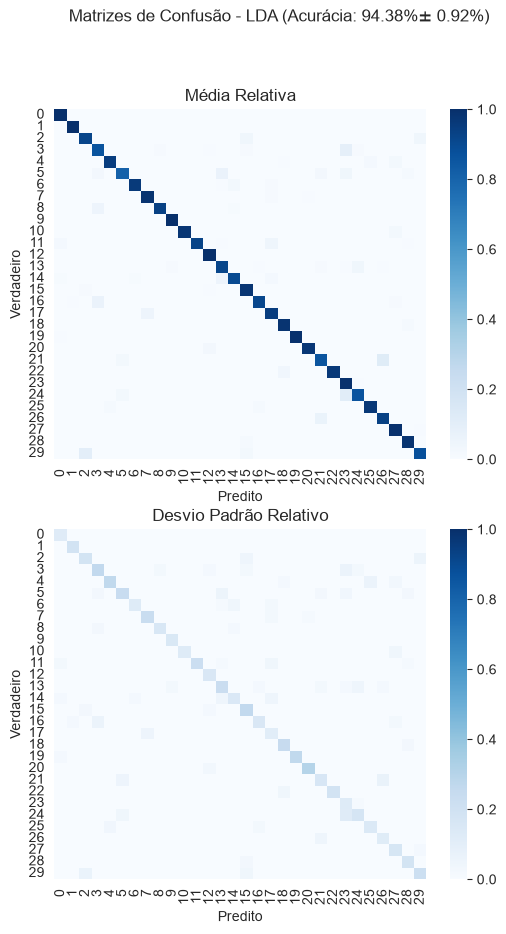

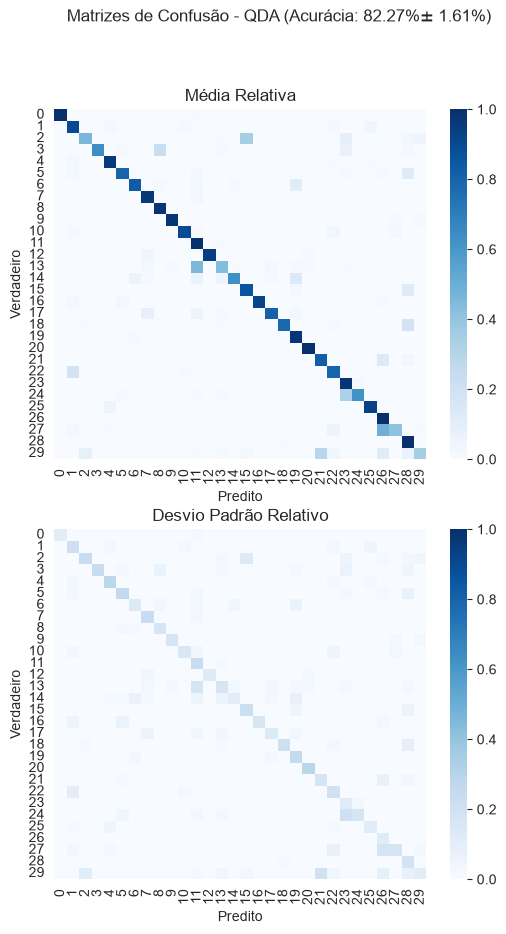

In [15]:
sementes_aleatorias = [42, 7, 21, 84, 100, 123, 456, 789, 101_112, 131_415]

naive_bayes_estocastico = GaussianNB()
lda_estocastico = LinearDiscriminantAnalysis()
qda_estocastico = QuadraticDiscriminantAnalysis(solver='eigen', shrinkage=1e-3)

naive_bayes_resultados = {"acurácias": [], "matrizes": []}
lda_resultados = {"acurácias": [], "matrizes": []}
qda_resultados = {"acurácias": [], "matrizes": []}

for s in sementes_aleatorias:
    # Split
    x_train, x_test, y_train, y_test = train_test_split(dados.drop([COLUNA_CLASSE], axis=1), dados[COLUNA_CLASSE], test_size=0.2, random_state=s, shuffle=True)
    
    # Treino
    naive_bayes_estocastico.fit(x_train, y_train)
    lda_estocastico.fit(x_train, y_train)
    qda_estocastico.fit(x_train, y_train)

    # Teste
    naive_bayes_predicoes = naive_bayes_estocastico.predict(x_test)
    lda_predicoes = lda_estocastico.predict(x_test)
    qda_predicoes = qda_estocastico.predict(x_test)

    # Avaliação - acuracia
    naive_bayes_acuracia = accuracy_score(y_test, naive_bayes_predicoes)
    lda_acuracia = accuracy_score(y_test, lda_predicoes)
    qda_acuracia = accuracy_score(y_test, qda_predicoes)

    # Armazenamento dos resultados - Naive Bayes
    naive_bayes_resultados["acurácias"].append(naive_bayes_acuracia)
    naive_bayes_resultados["matrizes"].append(confusion_matrix(y_test, naive_bayes_predicoes))

    # Armazenamento dos resultados - LDA
    lda_resultados["acurácias"].append(lda_acuracia)
    lda_resultados["matrizes"].append(confusion_matrix(y_test, lda_predicoes))

    # Armazenamento dos resultados - QDA
    qda_resultados["acurácias"].append(qda_acuracia)
    qda_resultados["matrizes"].append(confusion_matrix(y_test, qda_predicoes))

# Resultados
for modelo, resultados in [
    ("Naive Bayes", naive_bayes_resultados), 
    ("LDA", lda_resultados), 
    ("QDA", qda_resultados)
]:
    cm_media = np.mean(resultados["matrizes"], axis=0)
    cm_desvio_padrao = np.std(resultados["matrizes"], axis=0)

    cm_media_relativa = cm_media / cm_media.sum(axis=1)[:, np.newaxis]
    cm_desvio_padrao_relativa = cm_desvio_padrao / cm_media.sum(axis=1)[:, np.newaxis]

    acc_media = np.mean(resultados["acurácias"])
    acc_desvio_padrao = np.std(resultados["acurácias"])

    titulo = f"Matrizes de Confusão - {modelo} (Acurácia: {acc_media:.2%}$\\pm$ {acc_desvio_padrao:.2%})"
    fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(6, 10))
    hmap_args = {
        "annot": False,
        "cmap": "Blues",
        "xticklabels": [i for i in range(30)],
        "yticklabels": [i for i in range(30)],
        "vmin": 0,
        "vmax": 1,
    }
    sns.heatmap(cm_media_relativa, ax=axs[0], fmt=".2f",**hmap_args)
    sns.heatmap(cm_desvio_padrao_relativa, ax=axs[1], fmt=".2f",**hmap_args)

    axs[0].set_title("Média Relativa")
    axs[0].set_xlabel('Predito')
    axs[0].set_ylabel('Verdadeiro')
    axs[1].set_title("Desvio Padrão Relativo")
    axs[1].set_xlabel('Predito')
    axs[1].set_ylabel('Verdadeiro')
    fig.suptitle(titulo)


Tabela das métricas:

In [16]:
df_metricas = pd.DataFrame({
    "Modelo": ["Naive Bayes", "LDA", "QDA"],
    "Acurácia Média": [
        np.mean(naive_bayes_resultados["acurácias"]),
        np.mean(lda_resultados["acurácias"]),
        np.mean(qda_resultados["acurácias"])
    ],
    "Acurácia Desvio Padrão": [
        np.std(naive_bayes_resultados["acurácias"]),
        np.std(lda_resultados["acurácias"]),
        np.std(qda_resultados["acurácias"])
    ]
})

display(df_metricas.style.format({
    "Acurácia Média": "{:.2%}",
    "Acurácia Desvio Padrão": "{:.2%}"
}))

,Modelo,Acurácia Média,Acurácia Desvio Padrão
0,Naive Bayes,80.58%,1.78%
1,LDA,94.38%,0.92%
2,QDA,82.27%,1.61%


### Melhor classificador

O LDA é o melhor classificador, com acurácia média de 94.38% e desvio padrão de 0.92%.

### Intervalos de confiança 

Como o desvio-padrão real das acurácias enquanto variáveis randômicas gaussianas é desconhecido, a distribuição t de Student é a mais adequada para auxiliar na dedução dos intervalos de confiança.

Para um processo randômico i.i.d. com $N$ amostras, média amostral $\overline{X}$ e desvio-padrão amostral $s$, tem-se

$$
    \overline{X} - t_{\alpha, \nu} \frac{S}{\sqrt{N}} \leq \mu \leq \overline{X} + t_{\alpha, \nu} \frac{S}{\sqrt{N}}
$$

onde $\alpha$ é o nível de confiança desejado, $\nu=N-1$ a quantidade de graus de liberdade, e $\mu$ a média subjacente de $X$.

Os coeficientes $t_{\alpha, \nu}$ são aproximados numericamente e tabelados para vários $\alpha$ e $\nu$.
Para o caso desta questão, [tem-se](https://en.wikipedia.org/wiki/Student%27s_t-distribution#Table_of_selected_values)

$$
    t_{95\%, 9} = 2.262, \quad
    t_{99.8\%, 9} = 4.297
$$

O código abaixo calcula os intervalos a partir dos resultados do item 7.2 com base na equação e valores acima.

In [17]:
t_95 = 2.262
t_99 = 4.297

for c, t in [(95, t_95), (99.8, t_99)]:
    intervalos = {}
    
    amplitude_naive_bayes = t * np.std(naive_bayes_resultados["acurácias"]) / np.sqrt(len(naive_bayes_resultados["acurácias"]))
    min_naive_bayes = np.mean(naive_bayes_resultados["acurácias"]) - amplitude_naive_bayes
    max_naive_bayes = np.mean(naive_bayes_resultados["acurácias"]) + amplitude_naive_bayes
    intervalo_naive_bayes = (min_naive_bayes, max_naive_bayes, 2*amplitude_naive_bayes)
    
    amplitude_lda = t * np.std(lda_resultados["acurácias"]) / np.sqrt(len(lda_resultados["acurácias"]))
    min_lda = np.mean(lda_resultados["acurácias"]) - amplitude_lda
    max_lda = np.mean(lda_resultados["acurácias"]) + amplitude_lda
    intervalo_lda = (min_lda, max_lda, 2*amplitude_lda)

    amplitude_qda = t * np.std(qda_resultados["acurácias"]) / np.sqrt(len(qda_resultados["acurácias"]))
    min_qda = np.mean(qda_resultados["acurácias"]) - amplitude_qda
    max_qda = np.mean(qda_resultados["acurácias"]) + amplitude_qda
    intervalo_qda = (min_qda, max_qda, 2*amplitude_qda)

    intervalos["Naive Bayes"] = intervalo_naive_bayes
    intervalos["LDA"] = intervalo_lda
    intervalos["QDA"] = intervalo_qda

    display(pd.DataFrame(
        intervalos, 
        index=["Limite Inferior", "Limite Superior", "Delta"]).style.format("{:.2%}").set_caption(
            f"Intervalos de Confiança de {c}% para Acurácia"
        )
    )

,Naive Bayes,LDA,QDA
Limite Inferior,79.31%,93.72%,81.12%
Limite Superior,81.86%,95.03%,83.42%
Delta,2.55%,1.31%,2.30%


,Naive Bayes,LDA,QDA
Limite Inferior,78.16%,93.13%,80.08%
Limite Superior,83.01%,95.62%,84.46%
Delta,4.85%,2.49%,4.37%


O intervalos obtidos corroboram as médias e desvios-padrão médios das acurácias feitas anteriormente, que ranqueavam as médias e desvios como LDA > QDA > Naïve Bayes.

Em particular, os intervalos do LDA são mais estreitos que os do QDA, que por sua vez são similares em largura aos do Naïve Bayes. 
Isso provavelmente se deve ao fato de que o LDA é um modelo mais simples, com menos parâmetros a serem estimados, e portanto menos suscetível a variações nos dados de treino.
O QDA, por outro lado, é um modelo mais complexo, com mais parâmetros a serem estimados, e portanto mais suscetível a variações nos dados de treino.
O Naïve Bayes, apesar de também ser um modelo simples, é mais suscetível a variações nos dados de treino do que o LDA, pois assume independência entre as features, o que não é verdade para este dataset.